# 📊 ReadyToFit — Multi-Peak Curve Fitting

A guided example of using the **ReadyToFit** package for multi-peak curve fitting, parameter management, visualization, and area analysis.

## Table of Contents
1. [Installation & Imports](#installation--imports)
2. [Generate Synthetic Test Data](#1-generate-synthetic-test-data)
3. [Basic Multi-Peak Fit (Auto-Detection)](#2-basic-multi-peak-fit-auto-detection)
4. [Plot the Fit Result](#3-plot-the-fit-result)
5. [Fixed Parameters (Locking Peak Centers)](#4-fixed-parameters-locking-peak-centers)
6. [Manual Initial Guesses](#5-manual-initial-guesses)
7. [Bounds / Constraints](#6-bounds--constraints)
8. [All Peak Model Types](#7-all-peak-model-types)
9. [Peak Area Integration](#8-peak-area-integration)
10. [Standalone Peak Detection](#9-standalone-peak-detection)
11. [Finding Best Fit](#10-finding-best-fit)

---
## Installation & Imports

In [1]:
# Install from source (if not already installed)
# !pip install .

# Or directly from GitHub:
# !pip install git+https://github.com/MarcoVando/ReadyToFit.git

# Import the package
from readytofit import (
    fit_model,
    plot_fit_result,
    evaluate_peak_areas,
    area_integration,
    detect_peaks,
    estimate_initial_parameters,
)

import numpy as np
import matplotlib.pyplot as plt

print("ReadyToFit imported successfully! ✅")

ReadyToFit imported successfully! ✅


---
## 1. Generate Synthetic Test Data

Let's create a multi-peak signal with three Gaussian peaks and some noise.

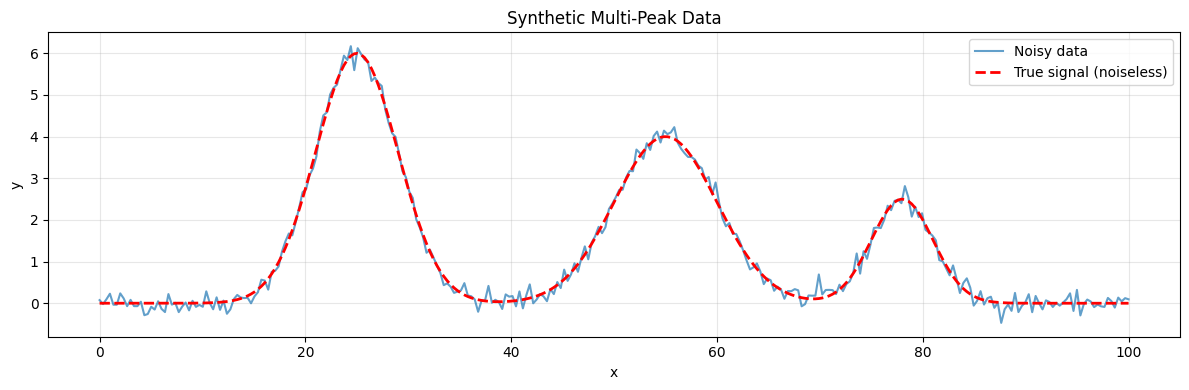

In [2]:
np.random.seed(42)  # Reproducibility

x = np.linspace(0, 100, 300)

# Three peaks with different positions, amplitudes, and widths
y_true = (
    6.0 * np.exp(-(x - 25)**2 / (2 * 4.0**2)) +   # Peak 1
    4.0 * np.exp(-(x - 55)**2 / (2 * 5.0**2)) +   # Peak 2
    2.5 * np.exp(-(x - 78)**2 / (2 * 3.0**2))     # Peak 3
)

# Add random noise
y = y_true + 0.15 * np.random.normal(size=len(x))

# Visualize the data
plt.figure(figsize=(12, 4))
plt.plot(x, y, label='Noisy data', alpha=0.7)
plt.plot(x, y_true, '--', color='red', label='True signal (noiseless)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Multi-Peak Data')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Basic Multi-Peak Fit (Auto-Detection)

This is the **recommended** approach. Simply define the peak models and let ReadyToFit automatically detect peaks and estimate initial parameters.

In [3]:
# Define peak structure: just the model types — parameters are auto-detected!
peaks = [
    {"model": "gauss"},
    {"model": "gauss"},
    {"model": "gauss"},
]

# Fit — p0 and initial parameters are auto-generated
result = fit_model(x, y, peaks)

print(f"✅ Fit successful!")
print(f"   RMSE: {result['rmse']:.4f}")
print()
print("Fitted parameters per peak:")
for i, peak_params in enumerate(result['params']):
    print(f"  Peak {i+1}: {peak_params}")

✅ Fit successful!
   RMSE: 0.1466

Fitted parameters per peak:
  Peak 1: {'A': np.float64(6.017852273860377), 'mu': np.float64(24.98035573218735), 'sigma': np.float64(3.981366380747016)}
  Peak 2: {'A': np.float64(4.044375572231079), 'mu': np.float64(55.02607913179244), 'sigma': np.float64(4.962559698683114)}
  Peak 3: {'A': np.float64(2.4715389825042795), 'mu': np.float64(78.00813673175175), 'sigma': np.float64(3.0464438261276117)}


---
## 3. Plot the Fit Result

Use the built-in `plot_fit_result` function to visualize:
- Raw data & total fit overlay
- Individual peak contributions (dashed lines)
- Filled peak areas
- Residual curve (offset for visibility)
- RMSE annotation

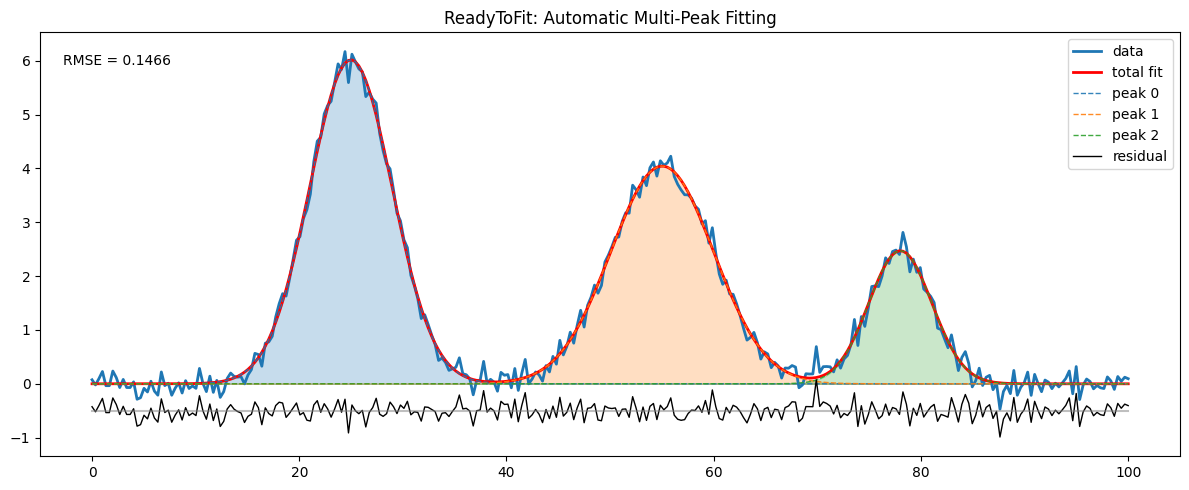

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_fit_result(
    x, y, result,
    show_residual=True,
    residual_offset=-0.5,
    show_rmse=True,
    fig=fig, ax=ax
)

ax.set_title('ReadyToFit: Automatic Multi-Peak Fitting')
plt.tight_layout()
plt.show()

### Inspect the full result dictionary

In [5]:
print("Keys in result dictionary:")
for key in result.keys():
    val = result[key]
    if isinstance(val, (np.ndarray, list)):
        print(f"  • '{key}': shape {len(val) if isinstance(val, list) else val.shape}")
    elif callable(val):
        print(f"  • '{key}': callable model function")
    else:
        print(f"  • '{key}': {val}")

Keys in result dictionary:
  • 'popt': shape (9,)
  • 'params': shape 3
  • 'param_names': shape 9
  • 'total_fit': shape (300,)
  • 'peak_fits': shape 3
  • 'residual': shape (300,)
  • 'rmse': 0.14658136640194996
  • 'p0': shape 9
  • 'bounds': shape 3
  • 'model_function': callable model function
  • 'param_slices': shape 3


---
## 4. Fixed Parameters (Locking Peak Centers)

If you know certain peak positions (e.g., from theory or prior experiments), you can **fix** them. Fixed parameters are removed from optimization and reinstated after fitting.

In [6]:
# Fix the center positions of peaks 2 and 3
peaks_fixed = [
    {"model": "gauss"},              # Peak 1: all parameters free
    {"model": "gauss", "mu": 55},    # Peak 2: center fixed at x=55
    {"model": "gauss", "mu": 78},    # Peak 3: center fixed at x=78
]

result_fixed = fit_model(x, y, peaks_fixed)

print(f"RMSE: {result_fixed['rmse']:.4f}")
print()
for i, p in enumerate(result_fixed['params']):
    print(f"Peak {i+1}: {p}")

# Verify mu was preserved exactly
assert result_fixed['params'][1]['mu'] == 55, "mu should be locked to 55!"
assert result_fixed['params'][2]['mu'] == 78, "mu should be locked to 78!"
print()
print("✅ Fixed mu values preserved correctly!")

RMSE: 0.1467

Peak 1: {'A': np.float64(6.017860882881732), 'mu': np.float64(24.980351062880445), 'sigma': np.float64(3.981353356948444)}
Peak 2: {'A': np.float64(4.044382470586123), 'sigma': np.float64(4.962462502768388), 'mu': 55}
Peak 3: {'A': np.float64(2.4713302193519864), 'sigma': np.float64(3.0470366230074184), 'mu': 78}

✅ Fixed mu values preserved correctly!


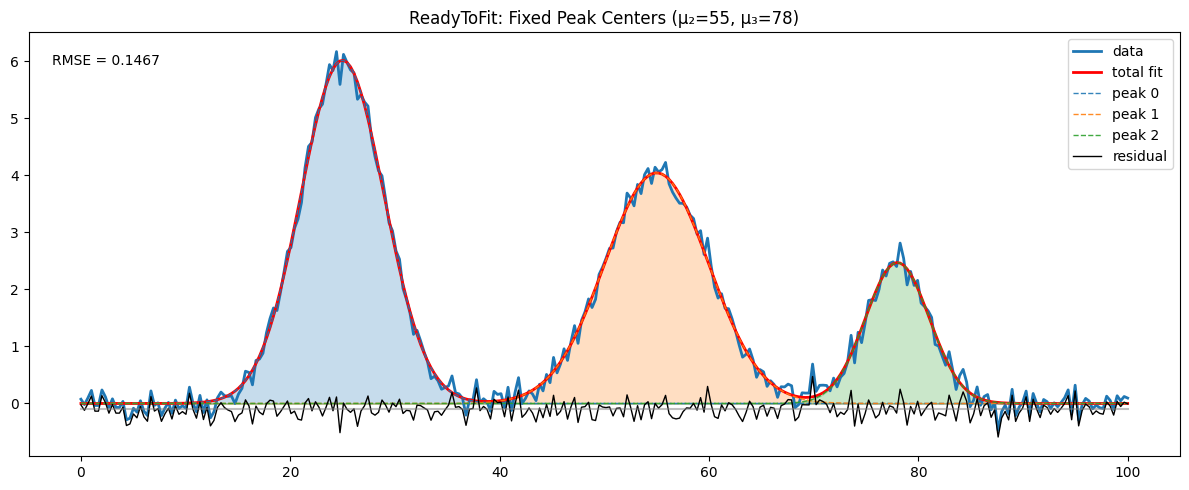

In [7]:
# Plot the fixed-peaks fit
fig, ax = plt.subplots(figsize=(12, 5))
plot_fit_result(x, y, result_fixed, fig=fig, ax=ax)
ax.set_title('ReadyToFit: Fixed Peak Centers (μ₂=55, μ₃=78)')
plt.tight_layout()
plt.show()

---
## 5. Manual Initial Guesses

If you have prior knowledge about the parameters, you can provide a manual `p0` to override automatic detection.

In [8]:
# Manual initial guesses
p0_manual = [
    {"A": 5.5, "mu": 26, "sigma": 5},   # Peak 1
    {"A": 3.8, "mu": 56, "sigma": 6},   # Peak 2
    {"A": 2.0, "mu": 79, "sigma": 4},   # Peak 3
]

result_manual = fit_model(x, y, peaks, p0=p0_manual)

print(f"RMSE: {result_manual['rmse']:.4f}")
for i, p in enumerate(result_manual['params']):
    print(f"Peak {i+1}: {p}")

RMSE: 0.1466
Peak 1: {'A': np.float64(6.01785227599477), 'mu': np.float64(24.980355733192603), 'sigma': np.float64(3.981366377785914)}
Peak 2: {'A': np.float64(4.044375605748069), 'mu': np.float64(55.02607910142541), 'sigma': np.float64(4.962559607485264)}
Peak 3: {'A': np.float64(2.471537802459409), 'mu': np.float64(78.0081357583605), 'sigma': np.float64(3.0464467370625643)}


---
## 6. Bounds / Constraints

You can apply bounds to constrain parameters during fitting. Use `None` for peaks where you want default bounds (unconstrained).

In [9]:
# Bounds per peak: dict mapping param_name -> (lower, upper)
# Use None for default (unconstrained)
bounds_manual = [
    None,                              # Peak 1: default bounds
    {"A": (0, 10), "mu": (40, 70)},   # Peak 2: constrain amplitude and center
    {"mu": (70, 90)},                  # Peak 3: only constrain center
]

result_bounds = fit_model(x, y, peaks, bounds=bounds_manual)

print(f"RMSE: {result_bounds['rmse']:.4f}")
for i, p in enumerate(result_bounds['params']):
    print(f"Peak {i+1}: {p}")

# Verify constraints were respected
assert result_bounds['params'][1]['mu'] >= 40 and result_bounds['params'][1]['mu'] <= 70, "mu_1 out of bounds!"
assert result_bounds['params'][2]['mu'] >= 70 and result_bounds['params'][2]['mu'] <= 90, "mu_2 out of bounds!"
print()
print("✅ All bounds respected!")

RMSE: 0.1466
Peak 1: {'A': np.float64(6.017852273860377), 'mu': np.float64(24.98035573218735), 'sigma': np.float64(3.981366380747016)}
Peak 2: {'A': np.float64(4.044375572231079), 'mu': np.float64(55.02607913179244), 'sigma': np.float64(4.962559698683114)}
Peak 3: {'A': np.float64(2.4715389825042795), 'mu': np.float64(78.00813673175175), 'sigma': np.float64(3.0464438261276117)}

✅ All bounds respected!


/Users/marco/Documents/Coding/Python/Projects/ReadyToFit/readytofit/parameters.py:361: UserWarning: Bounds must be a list of dictionaries (one per peak). Using defaults.
  warnings.warn(


---
## 7. All Peak Model Types

ReadyToFit supports multiple peak models. Each handles different physical scenarios:

/Users/marco/Documents/Coding/Python/Projects/ReadyToFit/readytofit/parameters.py:88: UserWarning: Missing parameter 'gamma' for peak 0. Using default value.
  warnings.warn(
/Users/marco/Documents/Coding/Python/Projects/ReadyToFit/readytofit/parameters.py:88: UserWarning: Missing parameter 'sigma' for peak 0. Using default value.
  warnings.warn(
/Users/marco/Documents/Coding/Python/Projects/ReadyToFit/readytofit/parameters.py:88: UserWarning: Missing parameter 'lam' for peak 0. Using default value.
  warnings.warn(
/Users/marco/Documents/Coding/Python/Projects/ReadyToFit/readytofit/fit_models.py:105: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


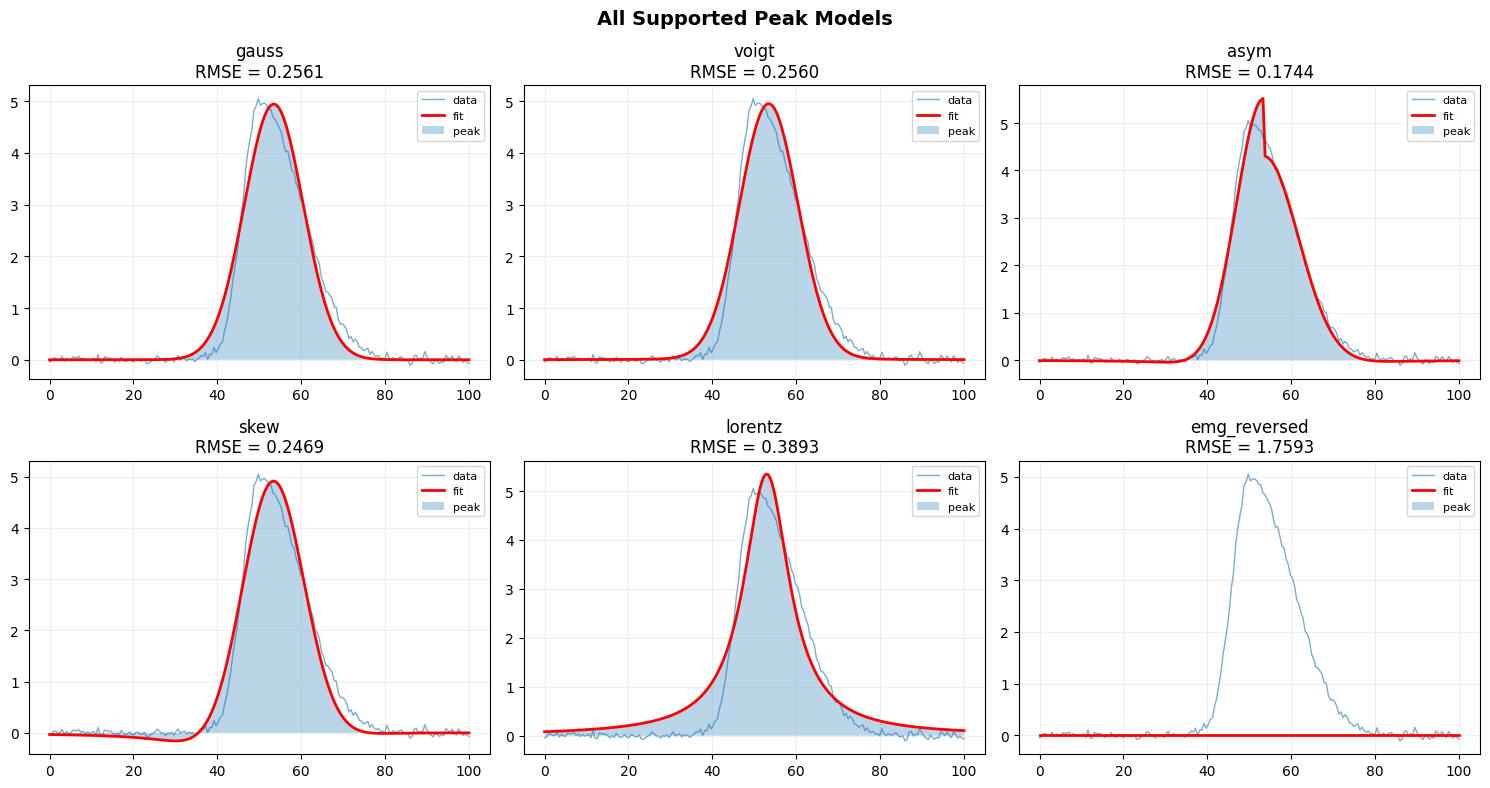

🏆 Best model for this data: 'asym' (RMSE = 0.1744)


In [10]:
# Generate a single asymmetric peak for comparing models
x_single = np.linspace(0, 100, 200)

# Asymmetric peak: wider on the right side
y_single = np.where(
    x_single < 50,
    5 * np.exp(-(x_single - 50)**2 / (2 * 4**2)),   # Left: narrow
    5 * np.exp(-(x_single - 50)**2 / (2 * 10**2))   # Right: wide
)
y_single += 0.05 * np.random.normal(size=len(x_single))

model_types = ['gauss', 'voigt', 'asym', 'skew', 'lorentz', 'emg_reversed']
results_dict = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, model_name in enumerate(model_types):
    res = fit_model(x_single, y_single, [{"model": model_name}])
    results_dict[model_name] = res
    
    ax = axes[idx]
    ax.plot(x_single, y_single, label='data', alpha=0.6, linewidth=1)
    ax.plot(x_single, res['total_fit'], 'r-', label='fit', linewidth=2)
    ax.fill_between(x_single, res['peak_fits'][0], alpha=0.3, label='peak')
    ax.set_title(f'{model_name}\nRMSE = {res["rmse"]:.4f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('All Supported Peak Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the best model
best_model = min(results_dict, key=lambda m: results_dict[m]['rmse'])
print(f"🏆 Best model for this data: '{best_model}' (RMSE = {results_dict[best_model]['rmse']:.4f})")

### Summary of Supported Models

| Model | Parameters | Use Case |
|-------|-----------|----------|
| `gauss` | A, μ, σ | Symmetric peaks (most common) |
| `lorentz` | A, μ, γ | Symmetric peaks with Lorentzian broadening |
| `voigt` | A, μ, σ, γ | Symmetric peaks with natural + Gaussian broadening |
| `asym` | A, μ, σL, σR, γ | Asymmetric peaks (different left/right widths) |
| `skew` | A, μ, σ, γ, α | Peaks with asymmetric tails |
| `emg_reversed` | A, μ, σ, λ | Left-skewed peaks (reversed exponentially modified Gaussian) |

**Legend:**
- **A**: Amplitude (peak height)
- **μ**: Center position *(can be fixed: `{"model": "gauss", "mu": 50}`)*
- **σ**: Standard deviation (Gaussian width)
- **σL, σR**: Left/right widths for asymmetric model
- **γ**: Lorentzian width (natural line broadening)
- **α**: Skew parameter
- **λ**: Exponential rate for EMG model

---
## 8. Peak Area Integration

Compute the area under each individual peak and the total signal using trapezoidal integration.

Peak Area Analysis
  Peak 1 area:       60.06
  Peak 2 area:       50.31
  Peak 3 area:       18.87
  ───────────────────────────────────
  Total area (sum):     129.24
  Total area (direct):  129.24

(Manual check: 129.24) ✅


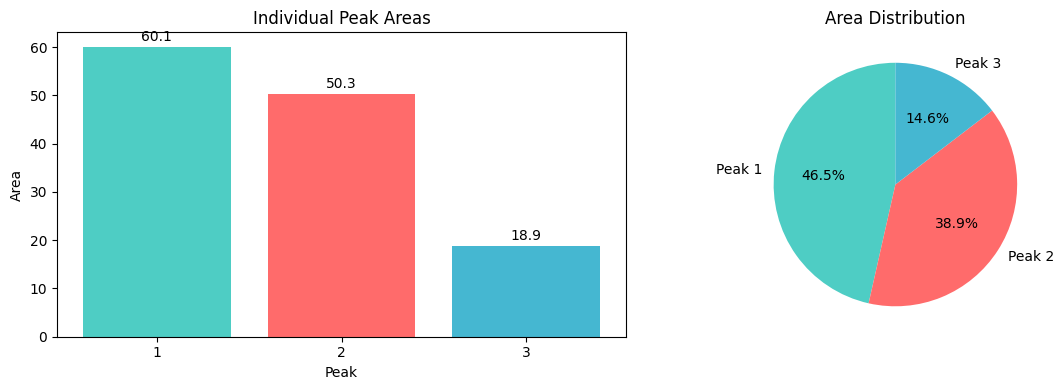

In [11]:
# Compute areas from the basic fit result
areas = evaluate_peak_areas(x, result)

print("Peak Area Analysis")
print("=" * 45)
for i, area in enumerate(areas['peaks']):
    print(f"  Peak {i+1} area:       {area:.2f}")
print(f"  {'─' * 35}")
print(f"  Total area (sum):     {sum(areas['peaks']):.2f}")
print(f"  Total area (direct):  {areas['total']:.2f}")

# Low-level area integration
manual_total = area_integration(result['total_fit'], x)
print(f"\n(Manual check: {manual_total:.2f}) ✅")

# Visualize areas as a pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']
bars = ax1.bar(range(1, len(areas['peaks']) + 1), areas['peaks'], color=colors)
ax1.set_xlabel('Peak')
ax1.set_ylabel('Area')
ax1.set_title('Individual Peak Areas')
ax1.set_xticks(range(1, len(areas['peaks']) + 1))
for bar, area in zip(bars, areas['peaks']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{area:.1f}', ha='center', va='bottom')

# Pie chart
ax2.pie(areas['peaks'], labels=[f'Peak {i+1}' for i in range(len(areas['peaks']))],
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Area Distribution')

plt.tight_layout()
plt.show()

---
## 9. Standalone Peak Detection

You can use the peak detection module directly without fitting.

Detected 3 peaks:

  Peak 1:
    Center (μ):    24.41
    Amplitude (A): 6.642
    Width (σ):     4.065
    Prominence:    0.538

  Peak 2:
    Center (μ):    55.85
    Amplitude (A): 4.698
    Width (σ):     4.789
    Prominence:    6.458

  Peak 3:
    Center (μ):    78.26
    Amplitude (A): 3.284
    Width (σ):     2.755
    Prominence:    0.454


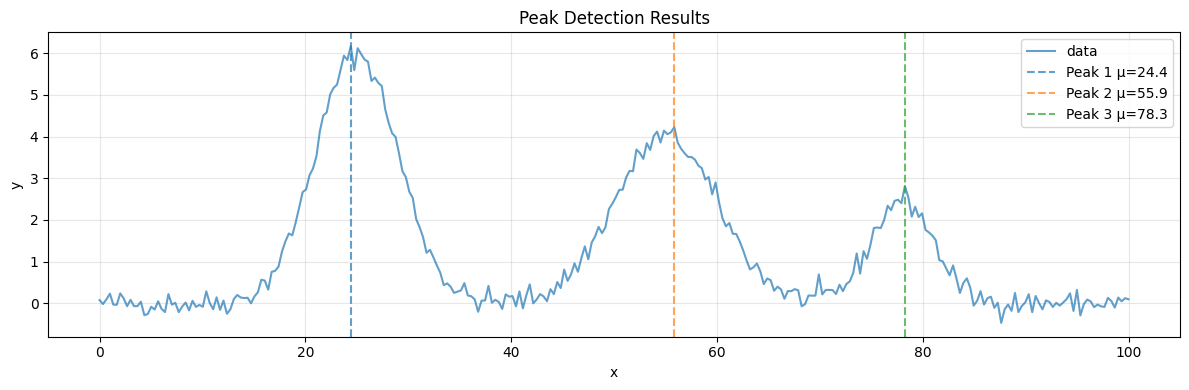


Estimated parameters for fitting:
  Peak 1: {'model': 'gauss', 'A': np.float64(6.6424597598200235), 'mu': np.float64(24.414715719063544), 'sigma': np.float64(4.065101301700123)}
  Peak 2: {'model': 'gauss', 'A': np.float64(4.698403039135668), 'mu': np.float64(55.852842809364546), 'sigma': np.float64(4.78885584689118)}
  Peak 3: {'model': 'gauss', 'A': np.float64(3.283887721107987), 'mu': np.float64(78.26086956521739), 'sigma': np.float64(2.754996835672006)}


In [12]:
# Auto-detect peaks in the data
detected = detect_peaks(x, y, n_peaks=3)

print(f"Detected {len(detected)} peaks:")
for i, peak in enumerate(detected):
    print(f"\n  Peak {i+1}:")
    print(f"    Center (μ):    {peak['mu']:.2f}")
    print(f"    Amplitude (A): {peak['A']:.3f}")
    print(f"    Width (σ):     {peak['sigma']:.3f}")
    print(f"    Prominence:    {peak['prominence']:.3f}")

# Visualize detected peaks
plt.figure(figsize=(12, 4))
plt.plot(x, y, label='data', alpha=0.7)
for i, peak in enumerate(detected):
    plt.axvline(peak['mu'], color=f'C{i}', linestyle='--', alpha=0.7,
                label=f"Peak {i+1} μ={peak['mu']:.1f}")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Peak Detection Results')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Estimate initial parameters from peak definitions
peak_defs = [{"model": "gauss"} for _ in range(3)]
estimated = estimate_initial_parameters(x, y, peak_defs)

print("\nEstimated parameters for fitting:")
for i, p in enumerate(estimated):
    print(f"  Peak {i+1}: {p}")

---
## 10. Finding Best Fit

The `find_best_fit` function runs the fit multiple times with perturbed initial guesses to find the best result.

In [14]:
from readytofit.fit_models import find_best_fit

# Run multiple iterations to find the best fit
results = find_best_fit(
    x, y, peaks,
    n_iterations=20,
    n_best_results=3,
    random_scale=0.3,
    debug=False
)

print("\nBest RMSEs found:")
for i, rmse in enumerate(sorted(results, reverse=False)):
    print(f"  #{i+1}: RMSE = {rmse:.4f}")

Iteration 1/20...
	Current RMSE: 0.1466 - Adding to best results
Iteration 2/20...
	Current RMSE: 0.5915 - Not better than worst of best RMSE: 0.1466
Iteration 3/20...
	Current RMSE: 0.1466 - Adding to best results
Iteration 4/20...
	Current RMSE: 0.5915 - Not better than worst of best RMSE: 0.1466
Iteration 5/20...
	Current RMSE: 0.5917 - Not better than worst of best RMSE: 0.1466
Iteration 6/20...
	Current RMSE: 0.5916 - Not better than worst of best RMSE: 0.1466
Iteration 7/20...
	Current RMSE: 0.5917 - Not better than worst of best RMSE: 0.1466
Iteration 8/20...
	Current RMSE: 0.1466 - Not better than worst of best RMSE: 0.1466
Iteration 9/20...
	Current RMSE: 0.5916 - Not better than worst of best RMSE: 0.1466
Iteration 10/20...
	Current RMSE: 3.6750 - Not better than worst of best RMSE: 0.1466
Iteration 11/20...
	Current RMSE: 4.2587 - Not better than worst of best RMSE: 0.1466
Iteration 12/20...
	Current RMSE: 0.5917 - Not better than worst of best RMSE: 0.1466
Iteration 13/20..

/Users/marco/Documents/Coding/Python/Projects/ReadyToFit/readytofit/fit_models.py:106: OptimizeWarning: Covariance of the parameters could not be estimated
  model_fun,


---
## Summary

### Key Takeaways

1. **Automatic fitting** — Just define peak models, and ReadyToFit handles the rest
2. **Fixed parameters** — Lock known values (e.g., peak centers) with `"mu": value`
3. **Flexible models** — Choose from Gaussian, Voigt, Asymmetric, Skewed, Lorentzian, EMG
4. **Constraints** — Apply bounds to parameters when you have prior knowledge
5. **Manual control** — Override `p0` and `bounds` when you need fine-grained control
6. **Visualization** — Built-in plotting with residuals and RMSE
7. **Area analysis** — Compute individual and total peak areas
8. **Peak detection** — Standalone utilities for locating peaks in data

### Public API

| Function | Purpose |
|----------|---------|
| `fit_model(x, y, peaks, p0, bounds)` | Main multi-peak fitting function |
| `plot_fit_result(x, y, result)` | Visualize fit with data, peaks, residuals |
| `detect_peaks(x, y, n_peaks)` | Automatically find peaks in data |
| `estimate_initial_parameters(x, y, peaks)` | Estimate p0 from data + peak definitions |
| `evaluate_peak_areas(x, result)` | Compute peak areas from fit results |
| `area_integration(y, x)` | Low-level numerical integration |

---
*Happy fitting! 🚀*